In [39]:
import numpy as np
import matplotlib.pyplot as plt

N = 25

# with randomized vectors
X = np.random.uniform(0, 5, N)
X.sort()
Y = np.random.uniform(0, 5, N)

Slope: -0.16122734802561467, Intercept: 2.6866465292157757


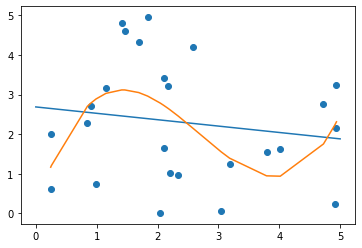

In [57]:
# Part A

A = np.vstack([X, np.ones(len(X))]).T

# Solve using least squares

m, c = np.linalg.lstsq(A, Y, rcond=None)[0]

print(f"Slope: {m}, Intercept: {c}")

plt.scatter(X, Y)
plt.plot(np.linspace(0, 5, N), np.linspace(0, 5, N)*m + c)

# solve using polyfit
coeff = np.polyfit(X, Y, 3)
poly = np.poly1d(coeff)


y_p = poly(X)
plt.plot(X, y_p)
plt.show()


In [53]:
def mse(y, y_p):
    return np.mean((y - y_p)**2)

def r_sq(y, y_p):
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_p)**2)
    return 1 - (ss_res / ss_total)


In [55]:
print(f"[MSE] linear: {mse(Y, np.linspace(0, 5, N)*m + c)}")
print(f"[MSE] polynomial: {mse(Y, y_p)}")

print(f"[RSQ] linear: {r_sq(Y, np.linspace(0, 5, N)*m + c)}")
print(f"[RSQ] polynomial: {r_sq(Y, y_p)}")

[MSE] linear: 2.1992075080881035
[MSE] polynomial: 1.7685953857369225
[RSQ] linear: 0.027629582020379573
[RSQ] polynomial: 0.21802293410643248


In [ ]:
"""
Part A Discussion:
The Polynomial fit has better MSE (lower) and
a better R-Squared value (higher), meaning it
is a better fit.
"""

[Degree 1]
MSE: 2.2090247759203248
RSQ: 0.023288918035590855
[Degree 2]
MSE: 2.1776378689290827
RSQ: 0.03716650792100107
[Degree 3]
MSE: 1.7685953857369225
RSQ: 0.21802293410643248
[Degree 4]
MSE: 1.7322185011029205
RSQ: 0.23410682177336373
[Degree 5]
MSE: 1.5728095398713853
RSQ: 0.30458882844728574
[Degree 6]
MSE: 1.4885729107142338
RSQ: 0.3418337023400372
[Degree 7]
MSE: 1.4273182934811357
RSQ: 0.36891717561078374
[Degree 8]
MSE: 1.4273100960332783
RSQ: 0.36892080007812944
[Degree 9]
MSE: 1.1873575931644067
RSQ: 0.4750147974166077


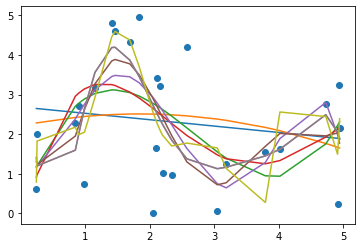

In [65]:
# Part B
plt.scatter(X, Y)

for i in range(1, 10):
    coeff_n = np.polyfit(X, Y, i)
    poly_n = np.poly1d(coeff_n)


    y_n = poly_n(X)
    plt.plot(X, y_n)
    
    print(f"[Degree {i}]")
    print(f"MSE: {mse(Y, y_n)}")
    print(f"RSQ: {r_sq(Y, y_n)}")

plt.show()

[MSE] polynomial: 1.7685953857369225
[RSQ] polynomial: 0.21802293410643248


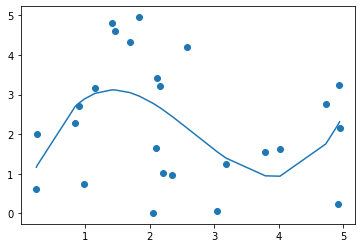

In [74]:
# challenge 3

def poly_vander(x, y, degree=1):
    V = np.vander(x, N=degree+1, increasing=True)
    VT_V = np.dot(V.T, V)
    VT_y = np.dot(V.T, y)
    coefficients = np.linalg.solve(VT_V, VT_y)
    return coefficients


# solve using new func
coeff_v = poly_vander(X, Y, 3)
poly_v = np.poly1d(coeff)

y_v = poly_v(X)

print(f"[MSE] polynomial: {mse(Y, y_v)}")
print(f"[RSQ] polynomial: {r_sq(Y, y_v)}")

plt.scatter(X, Y)
plt.plot(X, y_v)
plt.show()